In [3]:
import pandas as pd

# Load dataset
df = pd.read_excel('Player_Shot_on_target.xlsx')

# Filter for active forwards with at least 90 minutes played
strikers_df = df[(df['90s'] >= 1.0) & (df['PosGroup'] == 'FW')]

print("Data filtering complete.")
print(f"Total raw dataset size: {len(df)} players")
print(f"Filtered striker subset size: {len(strikers_df)} players")

Data filtering complete.
Total raw dataset size: 1006 players
Filtered striker subset size: 115 players


In [4]:
import pandas as pd

# Load and filter dataset
df = pd.read_excel('Player_Shot_on_target.xlsx')
strikers_df = df[(df['90s'] >= 1.0) & (df['PosGroup'] == 'FW')]

# Isolate target variable
sot_data = strikers_df['SoT/90']

# Check sample metrics and integrity
n = len(sot_data)
missing_values = sot_data.isnull().sum()

print(f"Sample Size (n): {n}")
print(f"Missing Values: {missing_values}")

# Central Limit Theorem (CLT) check
if n >= 30:
    print("CLT Assumption Met: Sample size (n >= 30) allows parametric inferential testing.")
else:
    print("Warning: Sample size is under 30.")

Sample Size (n): 115
Missing Values: 0
CLT Assumption Met: Sample size (n >= 30) allows parametric inferential testing.


Mean: 0.8345
Median: 0.7500
Standard Deviation: 0.7123
Range: [0.00, 2.98]


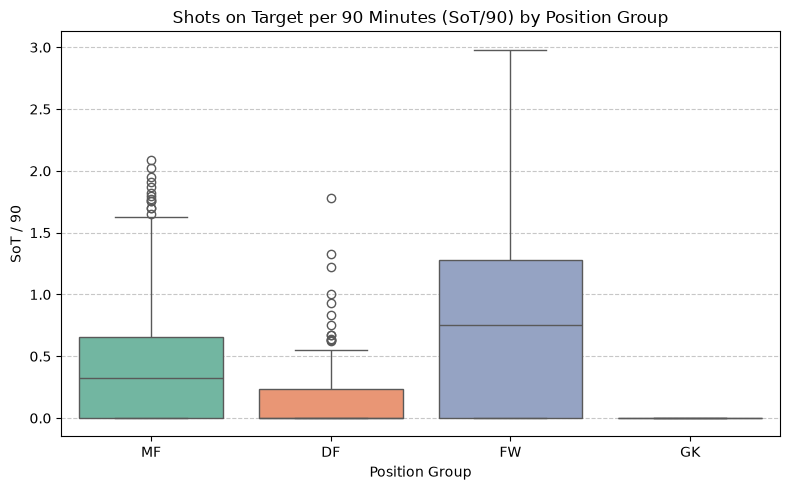

In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load and filter dataset
df = pd.read_excel('Player_Shot_on_target.xlsx')
strikers_df = df[(df['90s'] >= 1.0) & (df['PosGroup'] == 'FW')]
sot_data = strikers_df['SoT/90']

# Compute summary statistics
mean_val = sot_data.mean()
median_val = sot_data.median()
std_val = sot_data.std(ddof=1)
min_val = sot_data.min()
max_val = sot_data.max()

print(f"Mean: {mean_val:.4f}")
print(f"Median: {median_val:.4f}")
print(f"Standard Deviation: {std_val:.4f}")
print(f"Range: [{min_val:.2f}, {max_val:.2f}]")

# Visual Boxplot Comparison across Position Groups
plt.figure(figsize=(8, 5))
sns.boxplot(
    x='PosGroup', 
    y='SoT/90', 
    hue='PosGroup', 
    data=df[df['90s'] >= 1.0], 
    palette='Set2', 
    legend=False
)
plt.title('Shots on Target per 90 Minutes (SoT/90) by Position Group')
plt.xlabel('Position Group')
plt.ylabel('SoT / 90')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [6]:
import pandas as pd
import numpy as np
import scipy.stats as stats

# Load and filter dataset
df = pd.read_excel('Player_Shot_on_target.xlsx')
strikers_df = df[(df['90s'] >= 1.0) & (df['PosGroup'] == 'FW')]
sot_data = strikers_df['SoT/90']

# Calculate Standard Error and 95% Confidence Interval
n = len(sot_data)
mean_val = sot_data.mean()
std_val = sot_data.std(ddof=1)
se = std_val / np.sqrt(n)

ci95 = stats.t.interval(0.95, df=n-1, loc=mean_val, scale=se)

print(f"Standard Error (SE): {se:.4f}")
print(f"95% Confidence Interval: ({ci95[0]:.4f}, {ci95[1]:.4f})")

Standard Error (SE): 0.0664
95% Confidence Interval: (0.7029, 0.9661)


In [7]:
import pandas as pd
import scipy.stats as stats

# Load and filter dataset
df = pd.read_excel('Player_Shot_on_target.xlsx')
strikers_df = df[(df['90s'] >= 1.0) & (df['PosGroup'] == 'FW')]
sot_data = strikers_df['SoT/90']

# Run One-Sample t-Test against 0.50 benchmark
benchmark = 0.50
t_stat, p_val = stats.ttest_1samp(sot_data, benchmark)

print(f"Test Benchmark: {benchmark}")
print(f"t-Statistic: {t_stat:.4f}")
print(f"p-value: {p_val:.4e}")

# Automated statistical conclusion
if p_val < 0.05:
    print("Conclusion: Reject Null Hypothesis (H0). Active strikers significantly exceed the 0.50 benchmark.")
else:
    print("Conclusion: Fail to reject Null Hypothesis (H0).")

Test Benchmark: 0.5
t-Statistic: 5.0362
p-value: 1.7956e-06
Conclusion: Reject Null Hypothesis (H0). Active strikers significantly exceed the 0.50 benchmark.
